In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
import pandas as pd

orders = pd.read_csv("data/olist_orders_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

In [ ]:
df = orders.merge(customers, on="customer_id") \
           .merge(order_items, on="order_id") \
           .merge(products, on="product_id") \
           .merge(reviews, on="order_id")

In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112372 non-null  object 
 1   customer_id                    112372 non-null  object 
 2   order_status                   112372 non-null  object 
 3   order_purchase_timestamp       112372 non-null  object 
 4   order_approved_at              112357 non-null  object 
 5   order_delivered_carrier_date   111188 non-null  object 
 6   order_delivered_customer_date  110012 non-null  object 
 7   order_estimated_delivery_date  112372 non-null  object 
 8   customer_unique_id             112372 non-null  object 
 9   customer_zip_code_prefix       112372 non-null  int64  
 10  customer_city                  112372 non-null  object 
 11  customer_state                 112372 non-null  object 
 12  order_item_id                 

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1184
order_delivered_customer_date,2360
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [ ]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score
count,112372.000000,112372.000000,112372.000000,112372.000000,110774.000000,110774.000000,110774.000000,112354.000000,112354.000000,112354.000000,112354.000000,112372.000000
mean,35131.880691,1.196010,120.378962,19.977752,48.777583,786.793932,2.207124,2090.610882,30.152198,16.576811,23.001210,4.032473
std,29894.587573,0.691243,182.152386,15.781421,10.025179,651.609498,1.719787,3748.608093,16.139323,13.437792,11.707552,1.387849
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000
25%,11250.000000,1.000000,39.900000,13.070000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,4.000000
50%,24320.000000,1.000000,74.900000,16.250000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,5.000000
75%,59063.000000,1.000000,134.900000,21.150000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,5.000000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,5.000000


In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,500.0,19.0,8.0,13.0,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,400.0,19.0,13.0,19.0,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,420.0,24.0,19.0,21.0,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,450.0,30.0,10.0,20.0,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,250.0,51.0,15.0,15.0,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [ ]:

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

df.isnull().sum().sort_values(ascending=False)

,0
review_comment_title,98938
review_comment_message,64730
order_delivered_customer_date,2360
delivery_time,2360
product_category_name,1598
product_name_lenght,1598
product_photos_qty,1598
product_description_lenght,1598
order_delivered_carrier_date,1184
product_width_cm,18


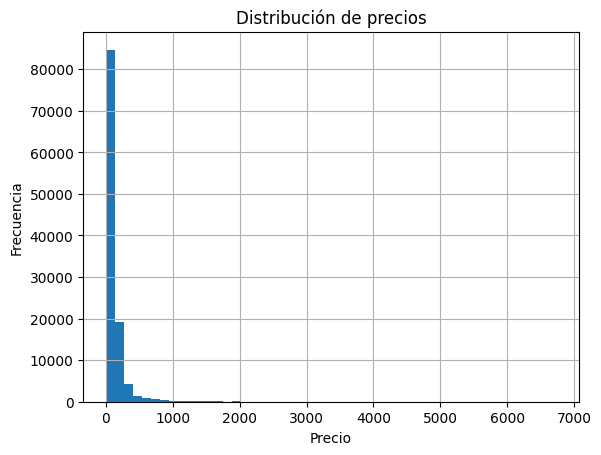

In [ ]:
import matplotlib.pyplot as plt

df['price'].hist(bins=50)
plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

El grafico demuestra que la mayoria de los productos del ecommerce tienen precios bajos pero existen algunos outliners que extienden el grafico hasta 7000. Recordemos que estos precios estan en BRL.

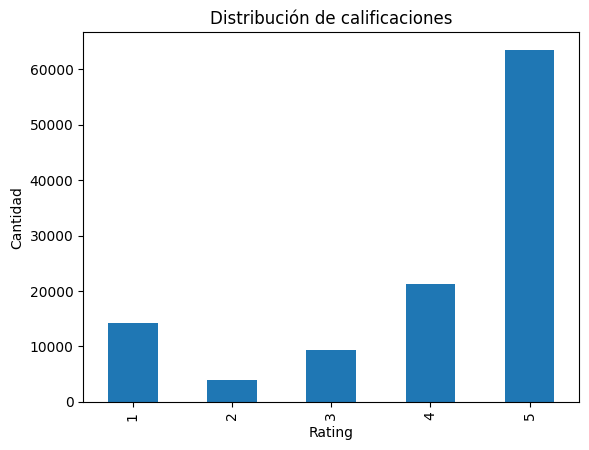

In [ ]:
df['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de calificaciones")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.show()

Interpretamos del grafico que el rating de la empresa es muy bueno. La mayor puntuacion consentra mucha mas cantidad de respuestas.





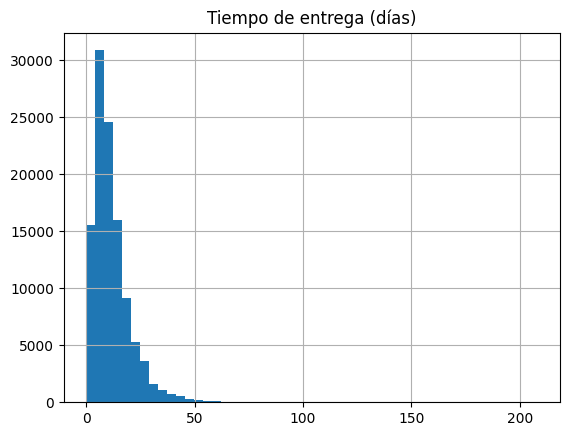

In [ ]:
df['delivery_time'].hist(bins=50)
plt.title("Tiempo de entrega (días)")
plt.show()

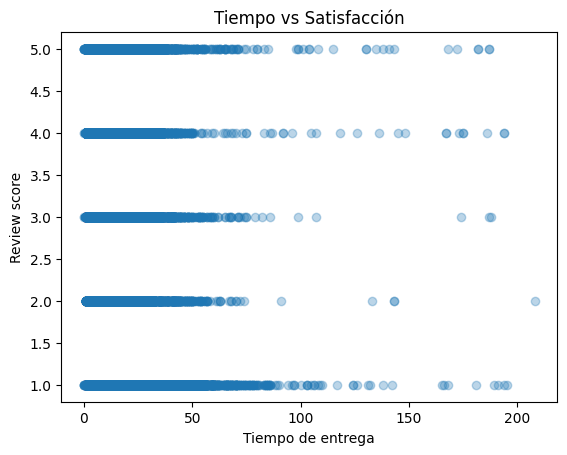

In [ ]:
plt.scatter(df['delivery_time'], df['review_score'], alpha=0.3)
plt.xlabel("Tiempo de entrega")
plt.ylabel("Review score")
plt.title("Tiempo vs Satisfacción")
plt.show()

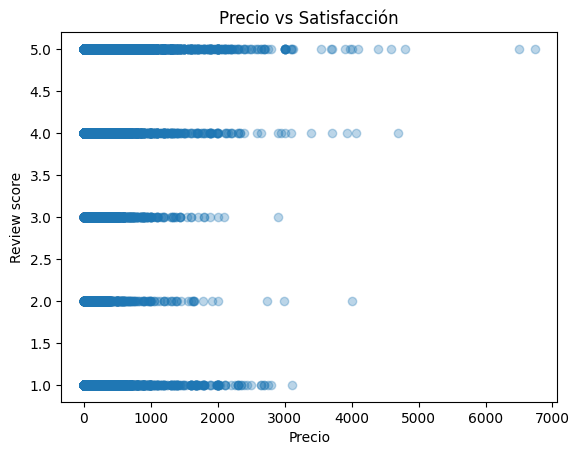

In [ ]:
plt.scatter(df['price'], df['review_score'], alpha=0.3)
plt.xlabel("Precio")
plt.ylabel("Review score")
plt.title("Precio vs Satisfacción")
plt.show()

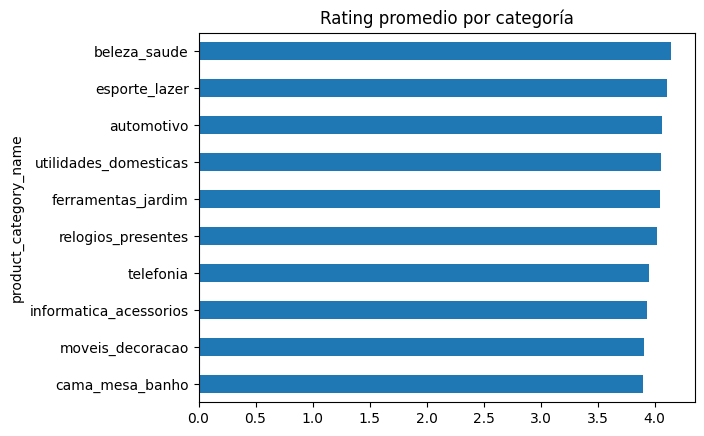

In [ ]:
top_categories = df['product_category_name'].value_counts().head(10).index

df[df['product_category_name'].isin(top_categories)] \
.groupby('product_category_name')['review_score'] \
.mean().sort_values().plot(kind='barh')

plt.title("Rating promedio por categoría")
plt.show()

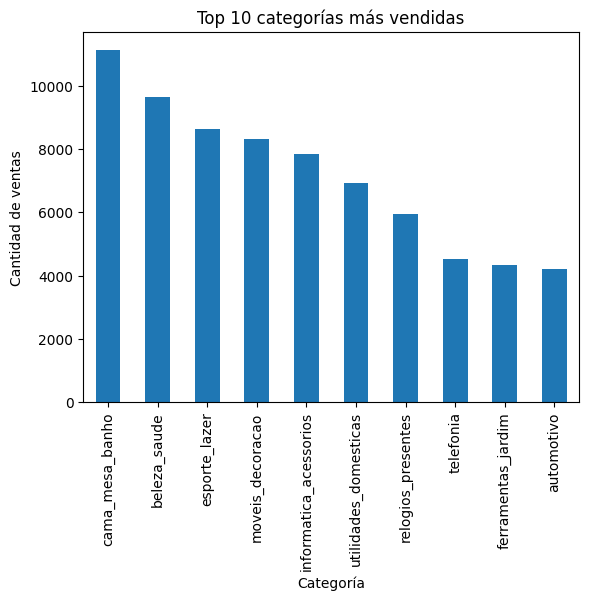

In [ ]:
top_categories = df['product_category_name'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.title("Top 10 categorías más vendidas")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de ventas")
plt.show()

In [ ]:
df['price'].median()
df['delivery_time'].mean()
df['review_score'].mean()



np.float64(4.032472502046773)

In [ ]:
df['delivery_time'].max()

208.0

In [ ]:
df['price'].mean()
df['price'].median()
df['price'].describe()

,price
count,112372.000000
mean,120.378962
std,182.152386
min,0.850000
25%,39.900000
50%,74.900000
75%,134.900000
max,6735.000000
